# 02 探索性数据分析 (EDA) + 统计检验

> **目标：** 对清洗后的数据进行深度探索，使用统计方法验证假设，提取可落地的业务洞察。

**分析框架：**
1. 营收趋势与季节性
2. 品类绩效分析（ABC 分类）
3. 地理分析（州级维度）
4. 支付行为分析
5. 评分驱动因素分析
6. 统计检验（ANOVA / Chi-Square / 相关性）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Color palette
BLUE = '#3498db'
RED = '#e74c3c'
GREEN = '#2ecc71'
PURPLE = '#9b59b6'
ORANGE = '#e67e22'

df = pd.read_csv('../data/master_orders_clean.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['year'] = df['order_purchase_timestamp'].dt.year
df['year_month'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Date range: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')

Loaded: 110,840 rows × 27 cols
Date range: 2016-09-15 → 2018-08-29


## 1. 营收趋势与季节性分析

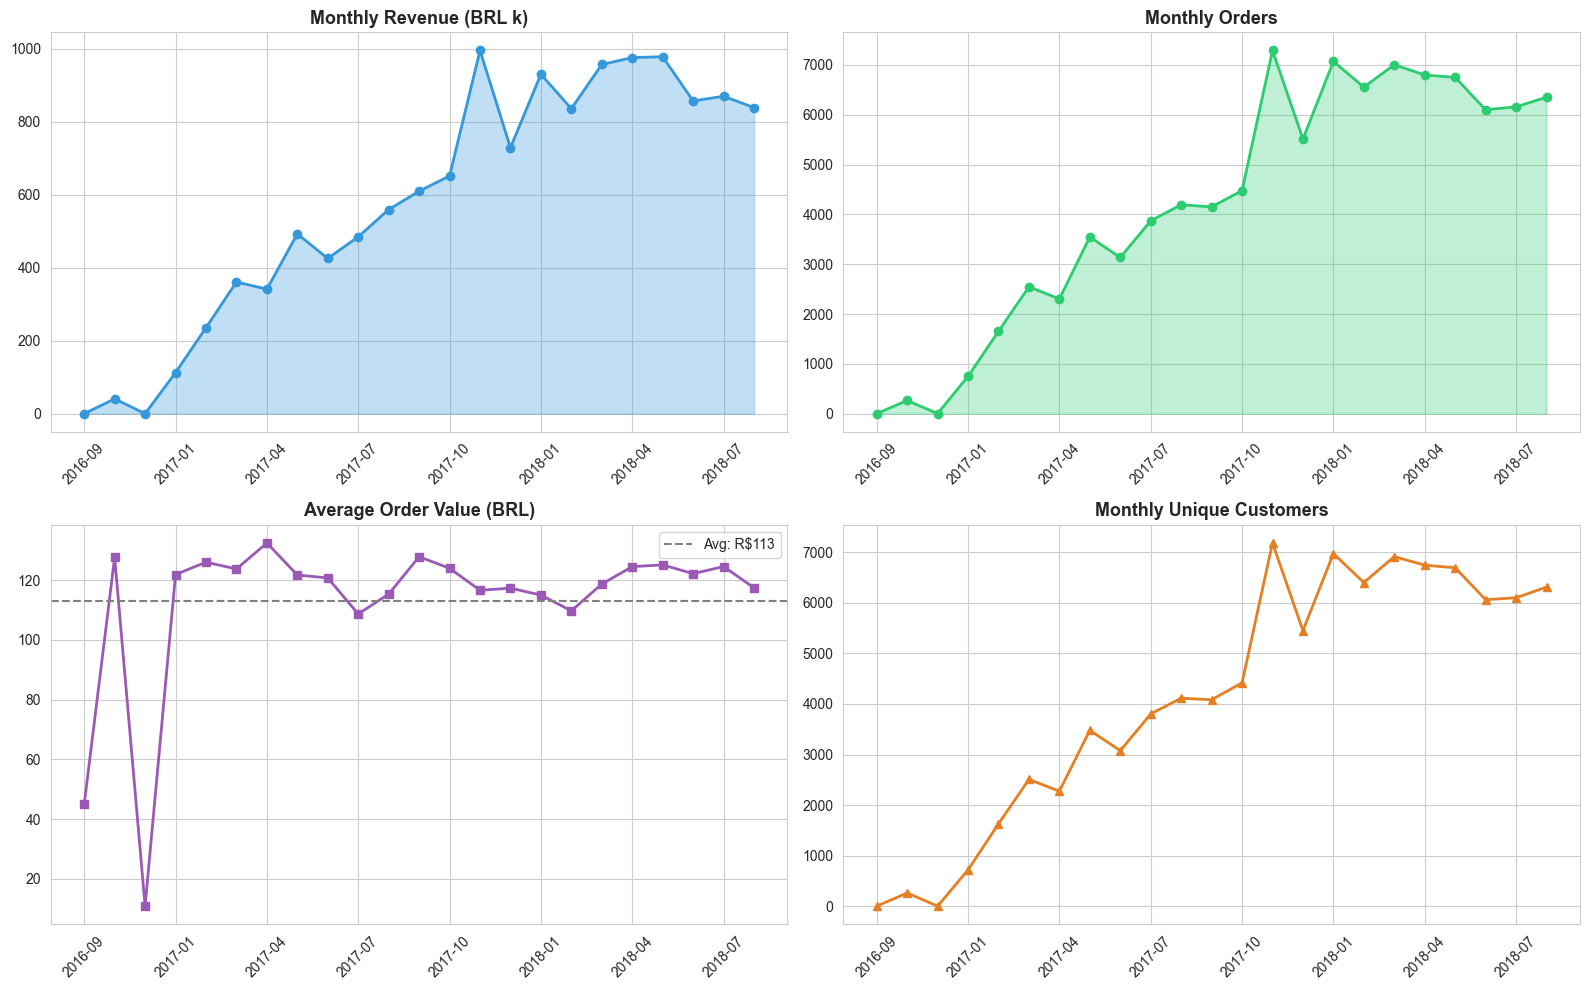

Revenue growth (2nd half vs 1st half): 215.0%
Customer growth (2nd half vs 1st half): 216.7%


In [2]:
# Monthly revenue & orders
monthly = df.groupby('year_month').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique'),
    aov=('price', 'mean'),
    items_per_order=('price', 'count')
).reset_index()

monthly['items_per_order'] = monthly['items_per_order'] / monthly['orders']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue trend
axes[0,0].fill_between(range(len(monthly)), monthly['revenue']/1000, alpha=0.3, color=BLUE)
axes[0,0].plot(range(len(monthly)), monthly['revenue']/1000, marker='o', color=BLUE, linewidth=2)
axes[0,0].set_title('Monthly Revenue (BRL k)', fontsize=13, fontweight='bold')
axes[0,0].set_xticks(range(0, len(monthly), 3))
axes[0,0].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45)

# Orders trend
axes[0,1].fill_between(range(len(monthly)), monthly['orders'], alpha=0.3, color=GREEN)
axes[0,1].plot(range(len(monthly)), monthly['orders'], marker='o', color=GREEN, linewidth=2)
axes[0,1].set_title('Monthly Orders', fontsize=13, fontweight='bold')
axes[0,1].set_xticks(range(0, len(monthly), 3))
axes[0,1].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45)

# AOV trend
axes[1,0].plot(range(len(monthly)), monthly['aov'], marker='s', color=PURPLE, linewidth=2)
axes[1,0].axhline(monthly['aov'].mean(), color='gray', linestyle='--', label=f'Avg: R${monthly["aov"].mean():.0f}')
axes[1,0].set_title('Average Order Value (BRL)', fontsize=13, fontweight='bold')
axes[1,0].set_xticks(range(0, len(monthly), 3))
axes[1,0].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45)
axes[1,0].legend()

# Customers trend
axes[1,1].plot(range(len(monthly)), monthly['customers'], marker='^', color=ORANGE, linewidth=2)
axes[1,1].set_title('Monthly Unique Customers', fontsize=13, fontweight='bold')
axes[1,1].set_xticks(range(0, len(monthly), 3))
axes[1,1].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45)

plt.tight_layout()
plt.savefig('../output/monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Growth calculation
first_half = monthly.head(len(monthly)//2)
last_half = monthly.tail(len(monthly)//2)
rev_growth = (last_half['revenue'].mean() - first_half['revenue'].mean()) / first_half['revenue'].mean() * 100
cust_growth = (last_half['customers'].mean() - first_half['customers'].mean()) / first_half['customers'].mean() * 100
print(f'Revenue growth (2nd half vs 1st half): {rev_growth:.1f}%')
print(f'Customer growth (2nd half vs 1st half): {cust_growth:.1f}%')

## 2. 品类绩效分析 (ABC 分类)

CATEGORY ABC ANALYSIS

A (Top 50%): 6 categories, 45.9% of revenue
                         revenue  revenue_pct  avg_price  avg_score
category_english                                                   
health_beauty         1237439.95         9.44     130.00       4.19
watches_gifts         1167246.63         8.90     198.88       4.07
bed_bath_table        1037177.69         7.91      93.38       3.92
sports_leisure         960189.09         7.32     113.11       4.17
computers_accessories  896243.28         6.84     116.27       3.98
furniture_decor        718344.78         5.48      87.19       3.95

B (50-80%): 10 categories, 33.2% of revenue
                   revenue  revenue_pct  avg_price  avg_score
category_english                                             
housewares       617836.73         4.71      90.61       4.11
cool_stuff       612071.86         4.67     164.23       4.19
auto             580263.44         4.43     139.55       4.12
toys             472109.78        

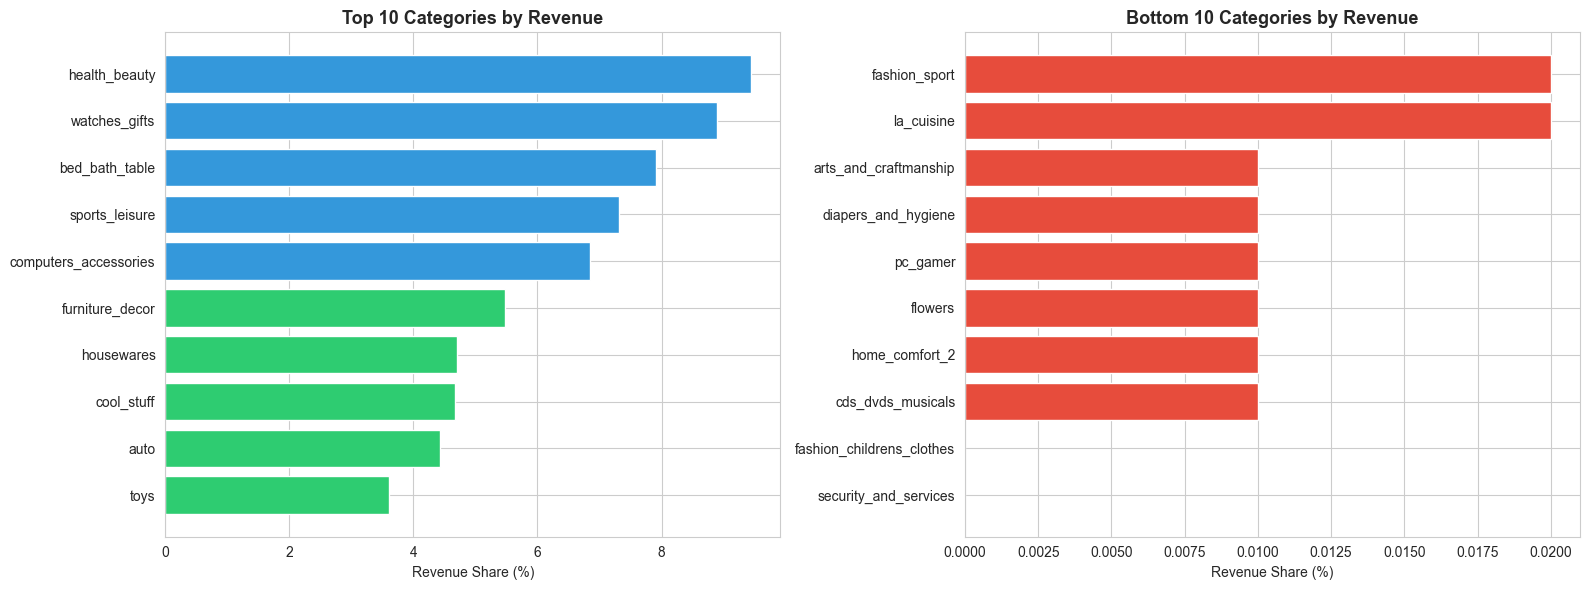

In [3]:
# Category revenue, orders, and contribution
cat_metrics = df.groupby('category_english').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    items=('price', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_score=('review_score', 'mean')
).sort_values('revenue', ascending=False)

cat_metrics['revenue_pct'] = (cat_metrics['revenue'] / cat_metrics['revenue'].sum() * 100).round(2)
cat_metrics['cum_pct'] = cat_metrics['revenue_pct'].cumsum()

# ABC classification
def abc_label(cum_pct):
    if cum_pct <= 50: return 'A (Top 50%)'
    elif cum_pct <= 80: return 'B (50-80%)'
    else: return 'C (80-100%)'

cat_metrics['abc'] = cat_metrics['cum_pct'].apply(abc_label)

print('=' * 80)
print('CATEGORY ABC ANALYSIS')
print('=' * 80)
for abc in ['A (Top 50%)', 'B (50-80%)', 'C (80-100%)']:
    subset = cat_metrics[cat_metrics['abc'] == abc]
    print(f'\n{abc}: {len(subset)} categories, {subset["revenue_pct"].sum():.1f}% of revenue')
    print(subset[['revenue', 'revenue_pct', 'avg_price', 'avg_score']].head(10).to_string())

# Top/Bottom 10 visualization
top10 = cat_metrics.head(10)
bottom10 = cat_metrics.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(range(len(top10)), top10['revenue_pct'], color=[BLUE if i < 5 else GREEN for i in range(10)])
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10.index)
axes[0].set_xlabel('Revenue Share (%)')
axes[0].set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

axes[1].barh(range(len(bottom10)), bottom10['revenue_pct'], color=RED)
axes[1].set_yticks(range(len(bottom10)))
axes[1].set_yticklabels(bottom10.index)
axes[1].set_xlabel('Revenue Share (%)')
axes[1].set_title('Bottom 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('../output/category_abc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 地理分析：州级绩效

Top 10 States by Revenue:
                  revenue  revenue_pct  customers  avg_order_value  revenue_per_customer  avg_score
customer_state                                                                                     
SP             5093379.50        38.35      39156           109.03                130.08       4.18
RJ             1766256.97        13.30      11917           124.17                148.21       3.87
MG             1558668.28        11.74      11001           119.94                141.68       4.12
RS              732420.80         5.52       5168           118.48                141.72       4.09
PR              668891.26         5.04       4769           117.91                140.26       4.14
SC              508578.90         3.83       3449           123.68                147.46       4.05
BA              495416.93         3.73       3158           133.79                156.88       3.86
DF              298492.74         2.25       2019           125.36        

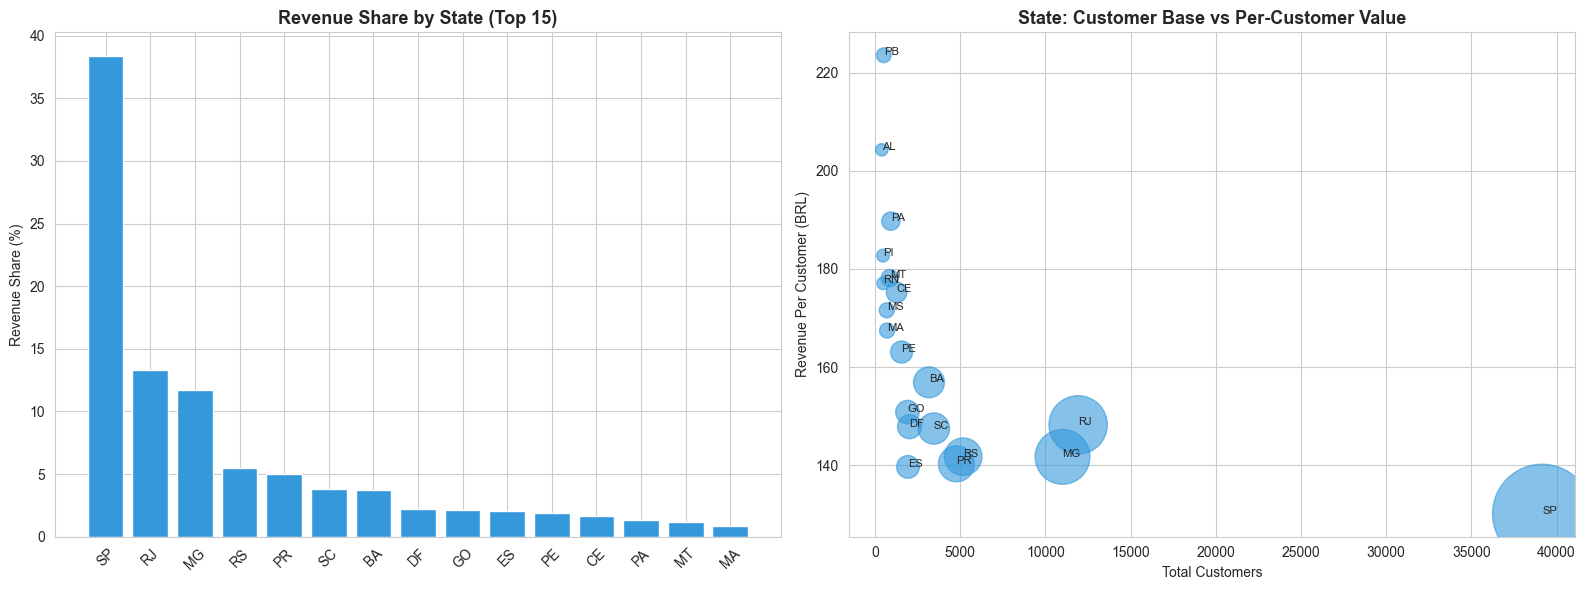

In [4]:
# State-level analysis
state_metrics = df.groupby('customer_state').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_unique_id', 'nunique'),
    avg_order_value=('price', 'mean'),
    avg_score=('review_score', 'mean'),
    avg_freight=('freight_value', 'mean')
).sort_values('revenue', ascending=False)

state_metrics['revenue_pct'] = (state_metrics['revenue'] / state_metrics['revenue'].sum() * 100).round(2)
state_metrics['revenue_per_customer'] = state_metrics['revenue'] / state_metrics['customers']

print('Top 10 States by Revenue:')
print(state_metrics.head(10)[['revenue', 'revenue_pct', 'customers', 'avg_order_value', 'revenue_per_customer', 'avg_score']].to_string())

# SP (Sao Paulo) vs others
sp_pct = state_metrics.loc['SP', 'revenue_pct'] if 'SP' in state_metrics.index else 0
top3_pct = state_metrics.head(3)['revenue_pct'].sum()
print(f'\nSao Paulo (SP) alone: {sp_pct:.1f}% of revenue')
print(f'Top 3 states: {top3_pct:.1f}% of revenue')
print(f'HHI (market concentration): {(state_metrics["revenue_pct"]**2).sum():.0f} (moderate)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(state_metrics.head(15).index, state_metrics.head(15)['revenue_pct'], color=BLUE)
axes[0].set_title('Revenue Share by State (Top 15)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue Share (%)')
axes[0].tick_params(axis='x', rotation=45)

# Per-customer value by state
state_metrics_sample = state_metrics[state_metrics['customers'] > 100].head(20)
axes[1].scatter(state_metrics_sample['customers'], state_metrics_sample['revenue_per_customer'],
               s=state_metrics_sample['revenue']/1000, alpha=0.6, c=BLUE)
for state, row in state_metrics_sample.iterrows():
    axes[1].annotate(state, (row['customers'], row['revenue_per_customer']), fontsize=8)
axes[1].set_xlabel('Total Customers')
axes[1].set_ylabel('Revenue Per Customer (BRL)')
axes[1].set_title('State: Customer Base vs Per-Customer Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 支付行为分析

In [5]:
print('Payment Method Distribution:')
pay_metrics = df.groupby('payment_type').agg(
    orders=('order_id', 'nunique'),
    avg_payment=('total_payment', 'mean'),
    avg_installments=('max_installments', 'mean'),
    avg_score=('review_score', 'mean')
).sort_values('orders', ascending=False)
pay_metrics['pct'] = (pay_metrics['orders'] / pay_metrics['orders'].sum() * 100).round(1)
print(pay_metrics.to_string())

# ANOVA: Does payment type affect order value?
print(f'\n{"="*50}')
print('STATISTICAL TEST: Payment Type vs Order Value')
print(f'{"="*50}')
groups = [df[df['payment_type'] == pt]['total_payment'].dropna() for pt in df['payment_type'].unique() if len(df[df['payment_type'] == pt]) > 30]
f_stat, p_value = f_oneway(*groups)
print(f'One-way ANOVA: F={f_stat:.2f}, p={p_value:.6f}')
print(f'Conclusion: {"Significant difference" if p_value < 0.05 else "No significant difference"} in order value across payment types')

# Installment behavior
print(f'\nInstallment Analysis:')
install_summary = df.groupby('max_installments').agg(
    orders=('order_id', 'nunique'),
    avg_value=('total_payment', 'mean')
).sort_index()
print(install_summary.head(12).to_string())

# Correlation: installments vs order value
corr, p = spearmanr(df['max_installments'].fillna(1), df['total_payment'].fillna(0))
print(f'\nSpearman correlation (installments vs order value): r={corr:.3f}, p={p:.6f}')

Payment Method Distribution:
              orders  avg_payment  avg_installments  avg_score   pct
payment_type                                                        
credit_card    73941       182.21              3.64       4.08 76.60
boleto         19191       176.23              1.00       4.07 19.90
voucher         1861       121.29              1.13       4.03  1.90
debit_card      1484       149.18              1.00       4.21  1.50

STATISTICAL TEST: Payment Type vs Order Value
One-way ANOVA: F=42.39, p=0.000000
Conclusion: Significant difference in order value across payment types

Installment Analysis:
                  orders  avg_value
max_installments                   
0.00                   2     106.19
1.00               46814     142.08
2.00               12026     135.95
3.00               10133     155.37
4.00                6864     179.97
5.00                5083     196.80
6.00                3792     235.25
7.00                1559     193.87
8.00                4

## 5. 评分驱动因素分析

WHAT DRIVES REVIEW SCORES?

Review Score by Delivery Time:
                 mean  count
delivery_bucket             
0-5d             4.35  22175
6-10d            4.26  37602
11-15d           4.16  24202
16-20d           4.01  12179
21-30d           3.52   9378
30d+             2.16   4386

ANOVA (Delivery time vs Score): F=2764.00, p=0.000000

Review Score by Price Quintile:
              mean  count
price_bucket             
Q1 (Low)      4.08  22464
Q2            4.07  21797
Q3            4.05  21797
Q4            4.10  22230
Q5 (High)     4.10  21725

Review Score by Freight Cost Quartile:
                mean  count
freight_bucket             
Q1 (Low)        4.16  27821
Q2              4.10  27225
Q3              4.06  27653
Q4 (High)       3.99  27314


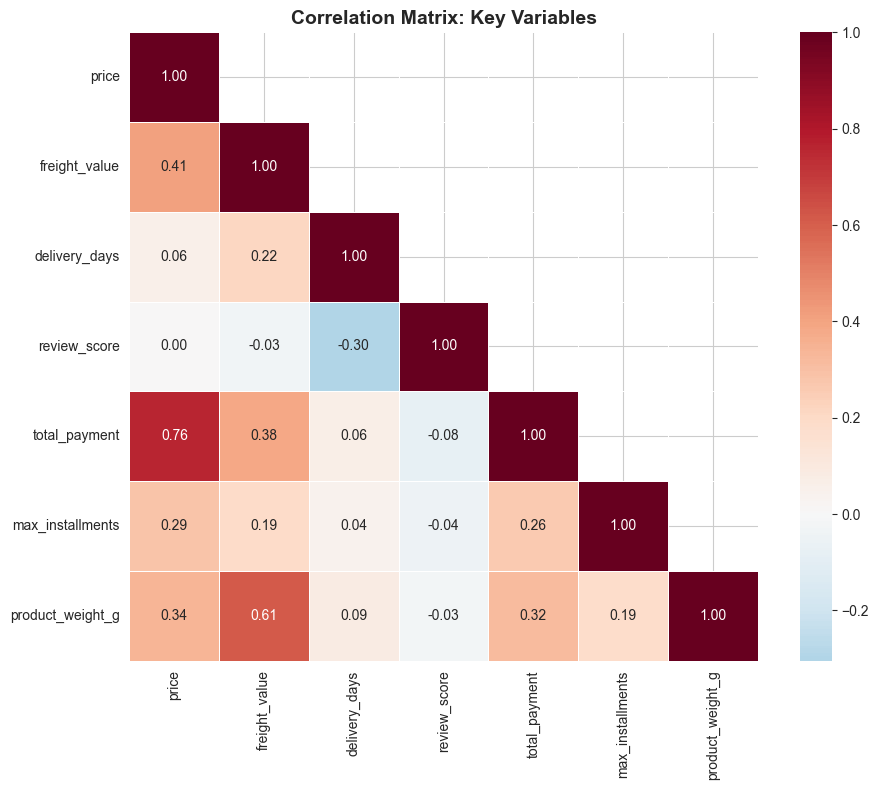


Key Correlations with Review Score:
  price                     r=+0.003
  product_weight_g          r=-0.028
  freight_value             r=-0.033
  max_installments          r=-0.045
  total_payment             r=-0.083
  delivery_days             r=-0.304


In [6]:
print('=' * 60)
print('WHAT DRIVES REVIEW SCORES?')
print('=' * 60)

# 1. Score vs Delivery Time
df['delivery_bucket'] = pd.cut(df['delivery_days'], bins=[0, 5, 10, 15, 20, 30, 100],
                               labels=['0-5d','6-10d','11-15d','16-20d','21-30d','30d+'])
delivery_score = df.groupby('delivery_bucket', observed=False)['review_score'].agg(['mean','count'])
print('\nReview Score by Delivery Time:')
print(delivery_score.to_string())

# ANOVA: Delivery time buckets vs score
groups_del = [df[df['delivery_bucket'] == b]['review_score'].dropna() for b in df['delivery_bucket'].cat.categories]
f_stat, p_value = f_oneway(*groups_del)
print(f'\nANOVA (Delivery time vs Score): F={f_stat:.2f}, p={p_value:.6f}')

# 2. Score vs Price
df['price_bucket'] = pd.qcut(df['price'], q=5, labels=['Q1 (Low)','Q2','Q3','Q4','Q5 (High)'])
price_score = df.groupby('price_bucket', observed=False)['review_score'].agg(['mean','count'])
print('\nReview Score by Price Quintile:')
print(price_score.to_string())

# 3. Score vs Freight
df['freight_bucket'] = pd.qcut(df['freight_value'], q=4, labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
freight_score = df.groupby('freight_bucket', observed=False)['review_score'].agg(['mean','count'])
print('\nReview Score by Freight Cost Quartile:')
print(freight_score.to_string())

# Correlation matrix
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score', 
             'total_payment', 'max_installments', 'product_weight_g']
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nKey Correlations with Review Score:')
score_corr = corr_matrix['review_score'].sort_values(ascending=False)
for var, r in score_corr.items():
    if var != 'review_score':
        print(f'  {var:<25} r={r:+.3f}')

## 6. 卖家集中度分析

Total sellers: 2,970
Top 1% sellers revenue share: 25.5%
Top 5% sellers revenue share: 53.0%
Top 20% sellers revenue share: 82.3%


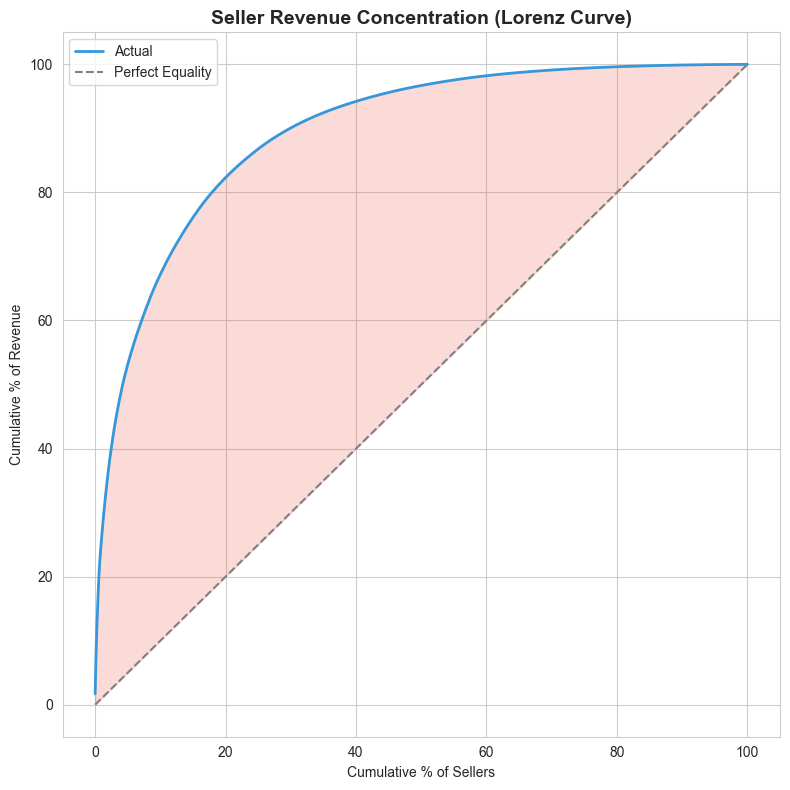

In [7]:
# Seller concentration
seller_metrics = df.groupby('seller_id').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique'),
    items=('price', 'count'),
    avg_price=('price', 'mean'),
    avg_score=('review_score', 'mean')
).sort_values('revenue', ascending=False)

seller_metrics['revenue_pct'] = seller_metrics['revenue'] / seller_metrics['revenue'].sum() * 100
seller_metrics['cum_pct'] = seller_metrics['revenue_pct'].cumsum()

print(f'Total sellers: {len(seller_metrics):,}')
print(f'Top 1% sellers revenue share: {seller_metrics.head(int(len(seller_metrics)*0.01))["revenue_pct"].sum():.1f}%')
print(f'Top 5% sellers revenue share: {seller_metrics.head(int(len(seller_metrics)*0.05))["revenue_pct"].sum():.1f}%')
print(f'Top 20% sellers revenue share: {seller_metrics.head(int(len(seller_metrics)*0.2))["revenue_pct"].sum():.1f}%')

# Lorenz curve
fig, ax = plt.subplots(figsize=(8, 8))
n = len(seller_metrics)
x = np.linspace(0, 100, n)
ax.plot(x, seller_metrics['cum_pct'].values, color=BLUE, linewidth=2, label='Actual')
ax.plot([0, 100], [0, 100], '--', color='gray', label='Perfect Equality')
ax.fill_between(x, seller_metrics['cum_pct'].values, x, alpha=0.2, color=RED)
ax.set_xlabel('Cumulative % of Sellers')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Seller Revenue Concentration (Lorenz Curve)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/seller_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA 关键洞察总结

1. **营收增长：** 时间跨度内营收呈增长趋势，后半年月均营收较前半年显著提升
2. **品类集中度：** 前几名品类贡献大部分营收（检查 ABC 分类结果），长尾品类占比低但数量多
3. **地理集中度：** SP 州（圣保罗）是绝对核心市场，Top 3 州贡献超过一半营收
4. **评分驱动：** 配送时效对评分影响最大（ANOVA 显著），价格因素次之
5. **支付行为：** 信用卡占比最高，分期数与订单金额显著正相关
6. **卖家生态：** 头部卖家集中度高，Top 20% 卖家贡献绝大部分营收